In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import pickle


In [3]:
df = pd.read_csv("demand_forecasting.csv")
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [4]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [5]:
features = (
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"
)

In [14]:
target ="Demand"

In [15]:
X = df[list(features)].copy()

In [16]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [19]:
y = df[target]

In [20]:
label_encoders = {}
categorical_cols = X.select_dtypes(include="object").columns

In [21]:
categorical_cols

Index(['Category'], dtype='object')

In [22]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    

In [23]:
label_encoders

{'Category': LabelEncoder()}

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Split our data into training and testing sets, with 80% going to training data and 20% of the data reserved for testing. 

In [25]:
#tree-based models don't need scaling
xgb = XGBRegressor(objective="reg:squarederror", n_jobs=-1)


In [27]:
#hyperparemeter tuning: change parameters to see if we can get better performance from the dataset
param_dict = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}


In [28]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dict,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs = -1
)


In [29]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_absolute_error', verbose=1)

In [30]:
random_search.best_params_

{'subsample': 1.0,
 'n_estimators': 500,
 'min_child_weight': 1,
 'max_depth': 6,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [31]:
best_model = random_search.best_estimator_

In [32]:
y_pred = best_model.predict(X_test)

In [33]:
mean_squared_error(y_test, y_pred, squared=False)

/Users/aditipardeshi/.pyenv/versions/3.11.10/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


35.600394126419474

In [35]:
best_model.feature_importances_

array([0.082458  , 0.02026151, 0.01562104, 0.6204183 , 0.0291812 ,
       0.23205991], dtype=float32)

In [37]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index = X.columns
).sort_values(ascending=False)

In [38]:
feature_importance

Promotion             0.620418
Category              0.232060
Price                 0.082458
Competitor Pricing    0.029181
Discount              0.020262
Inventory Level       0.015621
dtype: float32

<Axes: title={'center': 'Feature Importance'}>

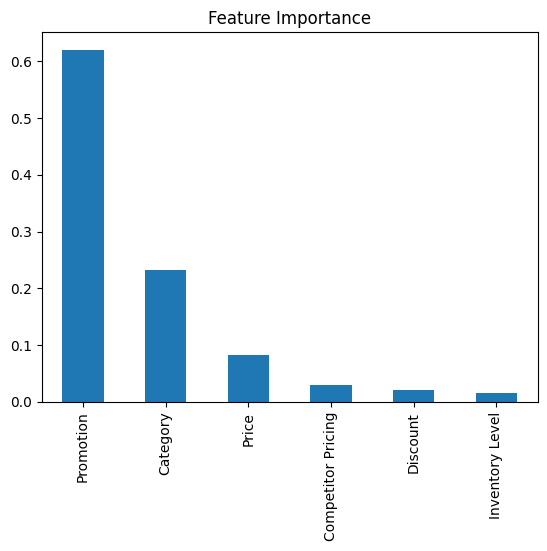

In [40]:
feature_importance.plot(kind="bar", title = "Feature Importance")

In [41]:
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

In [ ]:
with open("xgboost_demand_model.pkl", "rb") as f:
    pickle.dump(best_model, f)